# Autoencoder for Image Denoising

## Objective
The goal of this project is to build an Autoencoder that can remove noise from handwritten digit images using the MNIST dataset.

## Dataset
MNIST Dataset

Dataset Reference:
https://www.kaggle.com/datasets/awsaf49/mnist-dataset

The dataset was loaded using TensorFlow's built-in MNIST dataset API.

## Importing Required Libraries

In this step, we import the libraries required for numerical computations, data visualization, dataset loading, and building the Autoencoder model.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape

## Loading the MNIST Dataset

The MNIST dataset contains grayscale images of handwritten digits ranging from 0 to 9. It is widely used for image processing and deep learning experiments.

In [3]:
(x_train, _), (x_test, _) = mnist.load_data()

print("Training Shape:", x_train.shape)
print("Testing Shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Shape: (60000, 28, 28)
Testing Shape: (10000, 28, 28)


## Visualizing Original Images

Before introducing noise, it is useful to examine some original handwritten digit images from the dataset.

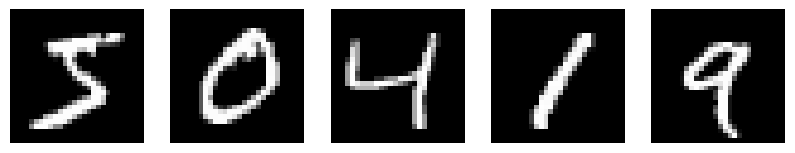

In [4]:
plt.figure(figsize=(10,4))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.axis('off')

plt.show()

## Data Normalization

The pixel values in the MNIST dataset range from 0 to 255. To improve training efficiency and model convergence, the values are scaled to the range [0,1].

In [5]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print("Minimum Pixel Value:", x_train.min())
print("Maximum Pixel Value:", x_train.max())

Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0


## Reshaping the Dataset

The Autoencoder requires image data in four dimensions:
(samples, height, width, channels).

Since MNIST images are grayscale, the channel dimension is set to 1.

In [6]:
x_train = x_train.reshape((-1, 28, 28, 1))
x_test = x_test.reshape((-1, 28, 28, 1))

print("Training Shape:", x_train.shape)
print("Testing Shape:", x_test.shape)

Training Shape: (60000, 28, 28, 1)
Testing Shape: (10000, 28, 28, 1)


## Adding Gaussian Noise

To simulate real-world image corruption, Gaussian noise is added to the original images.

The Autoencoder will learn to reconstruct the clean image from the noisy version.

In [7]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

## Visualizing Noisy Images

The following images show the effect of Gaussian noise on handwritten digits.

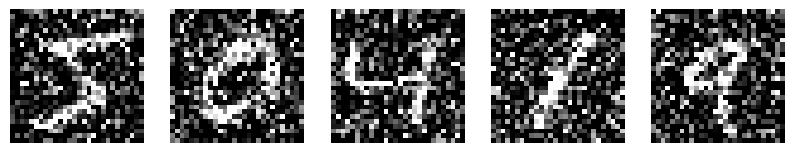

In [8]:
plt.figure(figsize=(10,4))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train_noisy[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

## Building the Autoencoder

An Autoencoder consists of two main components:

1. Encoder – Compresses the input image into a lower-dimensional representation.
2. Decoder – Reconstructs the original image from the compressed representation.

The model is trained to minimize the difference between the reconstructed image and the original clean image.

In [9]:
input_img = Input(shape=(28, 28, 1))

# Encoder
x = Flatten()(input_img)
encoded = Dense(128, activation='relu')(x)
encoded = Dense(64, activation='relu')(encoded)

# Decoder
decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(784, activation='sigmoid')(decoded)

decoded = Reshape((28, 28, 1))(decoded)

autoencoder = Model(input_img, decoded)

autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,192 (852.31 KB)

 Trainable params: 218,192 (852.31 KB)

 Non-trainable params: 0 (0.00 B)

## Training the Autoencoder

The model is trained using noisy images as input and clean images as target output. During training, the Autoencoder learns how to remove noise while preserving meaningful image features.

In [10]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.2453 - val_loss: 0.1774
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1636 - val_loss: 0.1517
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.1475 - val_loss: 0.1414
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 0.1391 - val_loss: 0.1351
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1332 - val_loss: 0.1297
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1292 - val_loss: 0.1275
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.1265 - val_loss: 0.1250
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1244 - val_loss: 0.1228
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1227 - val_loss: 0.1211
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1211 - val_loss: 0.1201


## Training Performance Analysis

To evaluate the learning process, the training and validation loss are plotted across epochs.

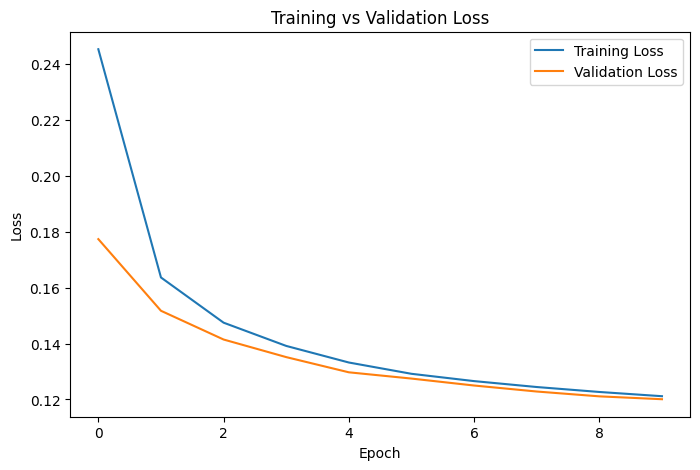

In [11]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

## Image Reconstruction

The trained Autoencoder is used to generate denoised versions of the noisy test images.

In [12]:
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


## Comparing Results

The following visualization compares:

1. Original Images
2. Noisy Images
3. Denoised Images generated by the Autoencoder

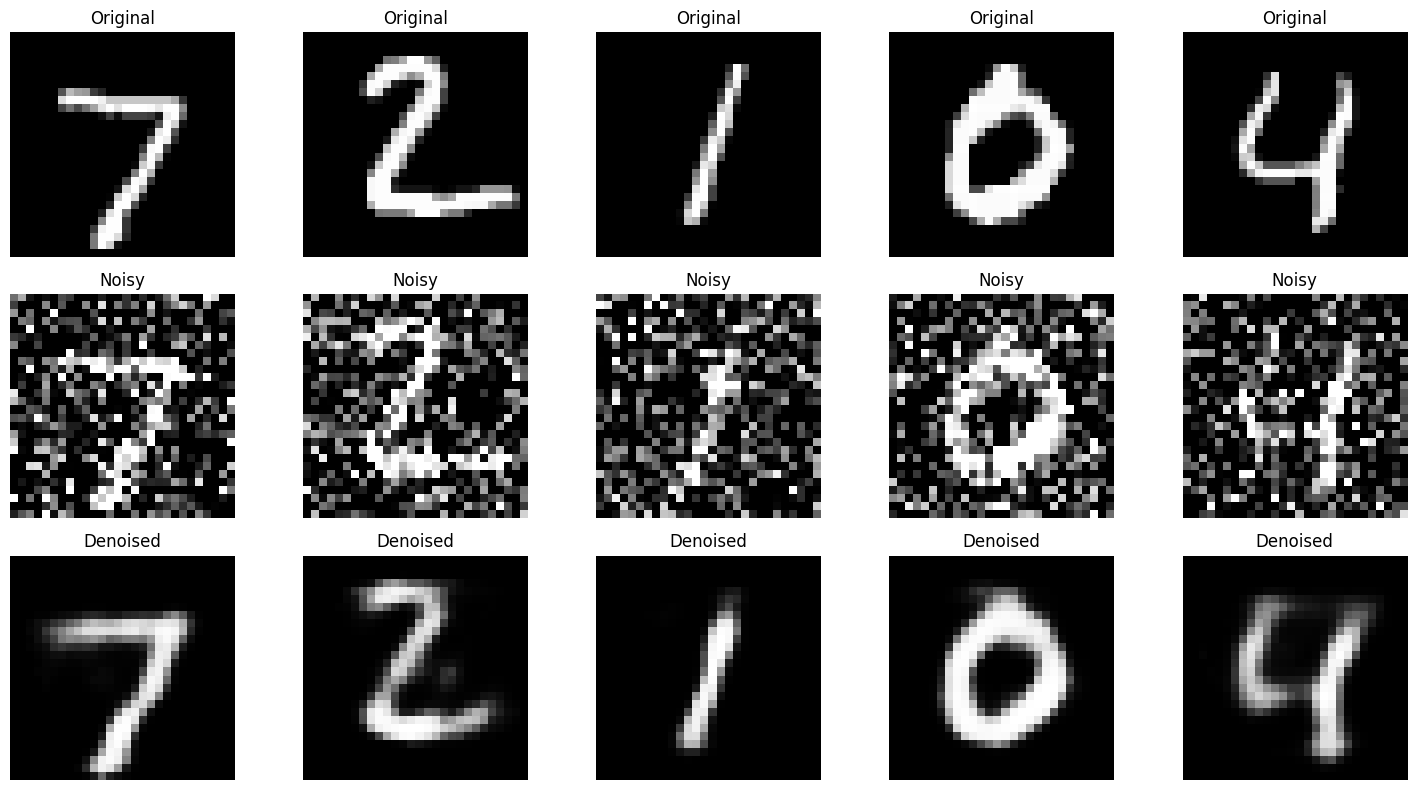

In [13]:
n = 5

plt.figure(figsize=(15,8))

for i in range(n):

    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Denoised
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Conclusion

This project demonstrated the use of an Autoencoder for image denoising on the MNIST dataset.

After introducing Gaussian noise into the images, the Autoencoder was trained to reconstruct clean digit images. The reconstructed outputs closely resemble the original images, showing that the model successfully learned meaningful feature representations.

The experiment highlights the effectiveness of Autoencoders in image restoration and reconstruction tasks.

## Results Summary

- Dataset Used: MNIST Handwritten Digits
- Noise Type: Gaussian Noise
- Optimizer: Adam
- Loss Function: Binary Crossentropy
- Epochs: 10
- Final Training Loss: ~0.121
- Final Validation Loss: ~0.120

The model achieved successful denoising and reconstruction of handwritten digit images.
